In [1]:

import sys
if 'google.colab' in sys.modules:
    !pip install utdquake

lib = None
lib = "/home/edc240000/UTDQuake"
if lib is not None:
    sys.path.append(lib)

# Version (Required)

In [2]:
import utdquake
from packaging.version import Version

current_version = Version(utdquake.__version__)
required_version = Version("0.0.20")

if current_version < required_version:
    raise Exception(f"Please update utdquake to at least version {required_version}")

Plots

In [3]:
import os
import pandas as pd
from obspy import UTCDateTime
from utdquake.core.event.catalog import read_catalog
from utdquake.tools.tracer import MyStream, plot_traces
from utdquake.clients.fdsn.client import Client
from matplotlib import pyplot as plt

project = "./custom_events" # see the example utd_window to understand these paths
stations_path = os.path.join(project,"stations.csv")
events_path = os.path.join(project,"origin.csv")
picks_path = os.path.join(project,"picks.db")
mags_path = os.path.join(project,"mags.db")

data

In [4]:
stations = pd.read_csv(stations_path)

catalog = read_catalog(events_path=events_path,
                       xy_epsg="EPSG:3116",
                       stations_path=stations_path)

picks = catalog.get_picks(picks_path=picks_path,author="manual")
data = picks.data
data = data.rename(columns={"time":"arrival_time"})
print(data.head(10))

        ev_id network station location channel phase_hint  \
0  tx2024hrey      TX    PB13       01     HHN          P   
1  tx2024hrey      4O    WB04       00     HHZ          P   
2  tx2024hrey      TX    PECS       00     HH2          P   
3  tx2024hrey      4O    WB03       00     HHN          P   
4  tx2024hrey      TX    PB33       00     HH1          P   
5  tx2024hrey      TX    PB40       00     HH1          P   
6  tx2024hrey      TX    PB24       00     HHE          P   
7  tx2024hrey      TX    PB43       00     HH1          P   
8  tx2024hrey      TX    PB07       00     HH2          P   
9  tx2024hrey      TX    PB20       00     HHE          P   

                arrival_time  time_lower_error  time_upper_error   author  \
0 2024-04-19 00:33:30.972988               0.3               0.3  Anestis   
1 2024-04-19 00:33:31.222610               0.3               0.3  Anestis   
2 2024-04-19 00:33:32.130765               0.2               0.2  Anestis   
3 2024-04-19 00:33:3

/home/edc240000/UTDQuake/utdquake/core/event/events.py:163: UserWarning: Some stations do not have coordinates. Activate debug mode in Events.get_picks to display them.
  warnings.warn("Some stations do not have coordinates. Activate debug mode in Events.get_picks to display them.")


waveforms

In [16]:
provider = "texnet"
client =  Client(provider)
st = client.get_waveforms(network="TX",station="PE*,PB*",
                          location="00",
                          channel="HHZ",
                           starttime=UTCDateTime("2024-04-19 09:23:03"),
                           endtime=UTCDateTime("2024-04-19 09:23:50"))
st = st.select(component="Z")
print(st)

40 Trace(s) in Stream:

TX.PB01.00.HHZ | 2024-04-19T09:23:03.000000Z - 2024-04-19T09:23:50.000000Z | 100.0 Hz, 4701 samples
...
(38 other traces)
...
TX.PECS.00.HHZ | 2024-04-19T09:23:03.000000Z - 2024-04-19T09:23:50.000000Z | 200.0 Hz, 9401 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


sort waveforms and little of processing

In [17]:
myst = MyStream(st.traces,stations) 
myst.sort_from_source(source=(-104.41,31.677),invert=True) # invert to plot from bottom to top
# myst.filter("bandpass", freqmin=1.0, freqmax=10.0) 
myst.detrend().normalize()
print(st)

40 Trace(s) in Stream:

TX.PB01.00.HHZ | 2024-04-19T09:23:03.000000Z - 2024-04-19T09:23:50.000000Z | 100.0 Hz, 4701 samples
...
(38 other traces)
...
TX.PECS.00.HHZ | 2024-04-19T09:23:03.000000Z - 2024-04-19T09:23:50.000000Z | 200.0 Hz, 9401 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


plot

PB03 P 2024-04-19 09:23:31.411860 texnet
PB10 P 2024-04-19 09:23:26.378561 texnet
PB12 P 2024-04-19 09:23:24.593351 texnet
PECS P 2024-04-19 09:23:23.923897 texnet
PECS S 2024-04-19 09:23:31.436654 texnet
PB11 P 2024-04-19 09:23:21.465586 texnet
PB24 P 2024-04-19 09:23:20.275996 texnet
PB33 P 2024-04-19 09:23:20.071428 texnet
PB31 P 2024-04-19 09:23:20.064384 texnet
PB31 S 2024-04-19 09:23:22.877455 texnet
PB34 P 2024-04-19 09:23:19.907177 texnet
PB34 S 2024-04-19 09:23:24.394995 texnet
PB25 P 2024-04-19 09:23:19.716453 texnet
PB25 S 2024-04-19 09:23:23.595736 texnet
PB20 P 2024-04-19 09:23:19.548818 texnet
PB20 S 2024-04-19 09:23:23.753549 texnet
PB23 P 2024-04-19 09:23:19.258466 texnet
PB23 S 2024-04-19 09:23:23.501985 texnet
PB26 P 2024-04-19 09:23:18.779046 texnet
PB26 S 2024-04-19 09:23:22.399455 texnet
PB29 P 2024-04-19 09:23:16.118725 texnet
PB29 S 2024-04-19 09:23:18.086642 texnet
PB37 P 2024-04-19 09:23:15.928516 texnet
PB37 S 2024-04-19 09:23:17.537533 texnet
PB28 P 2024-04-1

/home/edc240000/UTDQuake/utdquake/tools/tracer.py:180: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


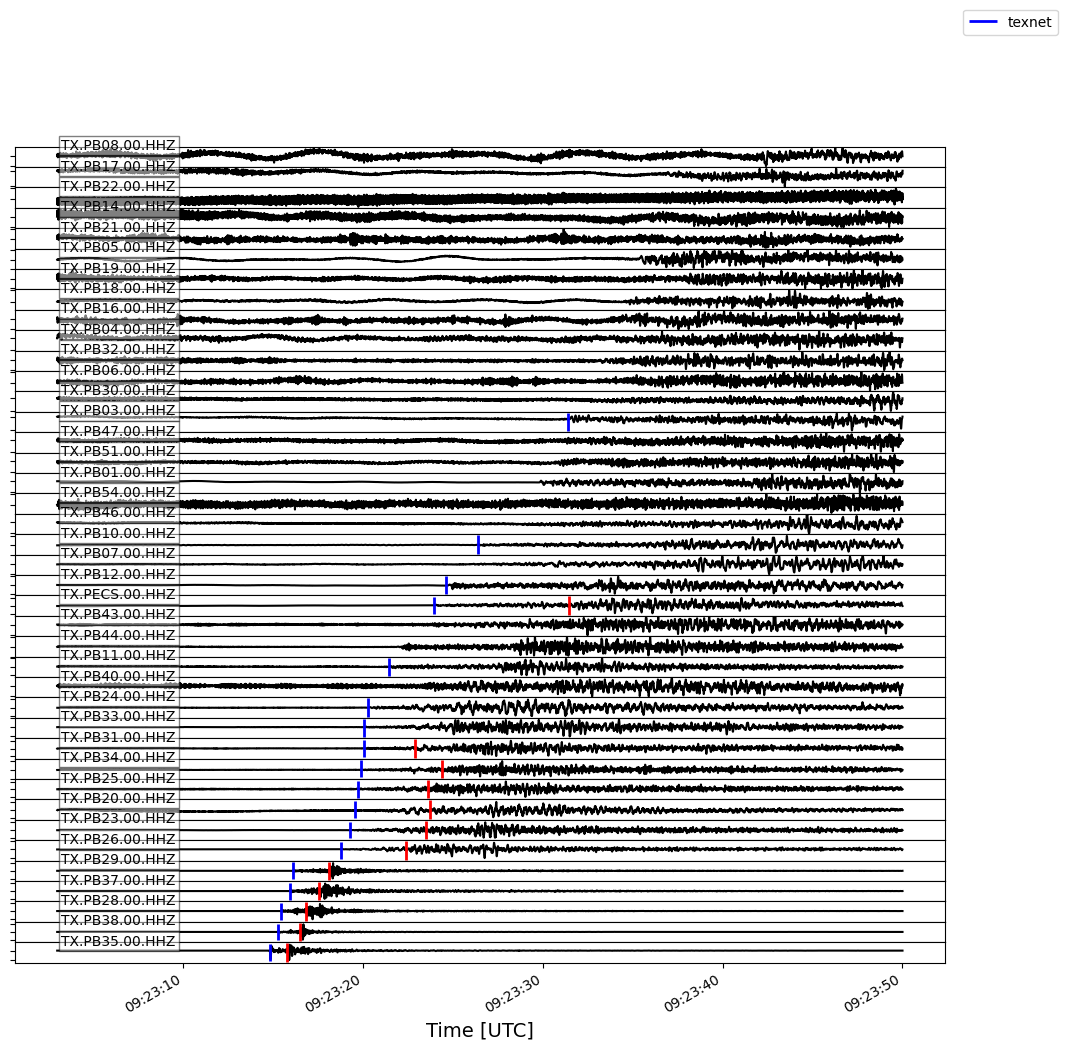

(<Figure size 1200x1200 with 40 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [UTC]'>],
       dtype=object))

In [ ]:
color_authors = {
    "texnet": {"P": "blue", "S": "red"},
}

picks_list = {"texnet":data}

fig,ax,legend_elements = plot_traces(myst,picks_list,
                                     color_authors)

fig.legend(handles=legend_elements, 
            loc='upper right',  
            fontsize=18,
            title_fontsize=18,
            title="Phases")

# Make the title bold
legend = fig.legends[-1]  # get the last legend added to the figure
legend.get_title().set_weight('bold')

savefig="./fig_ttracer.png"
fig.savefig(savefig, dpi=300, bbox_inches='tight')
plt.show()
